In [31]:
import pandas as pd

#laoding input file data manually 
df = pd.read_csv("/Users/rkafle/Desktop/Research_AI/clinical_genotype_HGB.csv")

# Table 1:Identifiers and Demographics
cols_table1 = ['wihsid', 'bsdate', 'bsvisit', 'dob', 'status']
table1 = df[cols_table1]

#convert numeric date columns to actual dates
base_date = pd.Timestamp('1960-01-01')
table1['bsdate'] = base_date + pd.to_timedelta(table1['bsdate'], unit='D')
table1['dob'] = base_date + pd.to_timedelta(table1['dob'], unit='D')


print(table1.head())
print(table1.info())


       wihsid     bsdate  bsvisit        dob  status
0  10100014.0 1994-11-15      1.0 1956-02-13     2.0
1  10100014.0 1994-11-15      1.0 1956-02-13     2.0
2  10100014.0 1994-11-15      1.0 1956-02-13     2.0
3  10100014.0 1994-11-15      1.0 1956-02-13     2.0
4  10100040.0 1994-12-12      1.0 1961-09-07     2.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45920 entries, 0 to 45919
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   wihsid   45919 non-null  float64       
 1   bsdate   45919 non-null  datetime64[ns]
 2   bsvisit  45919 non-null  float64       
 3   dob      45919 non-null  datetime64[ns]
 4   status   45919 non-null  float64       
dtypes: datetime64[ns](2), float64(3)
memory usage: 1.8 MB
None


In [32]:

# Remove duplicates and handle missing
table1 = table1.drop_duplicates().dropna(subset=['wihsid'])

# Convert status to categorical
status_map = {
    1: "Negative",
    2: "Prevalent",
    4: "Converter",
    5: "Converter_Death"
}
table1['status_label'] = table1['status'].map(status_map)



In [33]:
# Example: derive approximate age at baseline
table1['age_baseline'] = (table1['bsdate'] - table1['dob']).dt.days / 365.25

# Basic statistics
print(table1.groupby('status_label')['age_baseline'].describe())

                  count       mean        std        min        25%  \
status_label                                                          
Converter          16.0  40.239220   7.610911  24.624230  34.650240   
Converter_Death     1.0  30.067077        NaN  30.067077  30.067077   
Negative          759.0  36.803961  10.086864  18.113621  28.698152   
Prevalent        2076.0  38.077199   8.687529  17.141684  31.696099   

                       50%        75%        max  
status_label                                      
Converter        41.572895  47.225188  49.467488  
Converter_Death  30.067077  30.067077  30.067077  
Negative         36.761123  43.801506  60.407940  
Prevalent        37.514031  43.862423  68.711841  


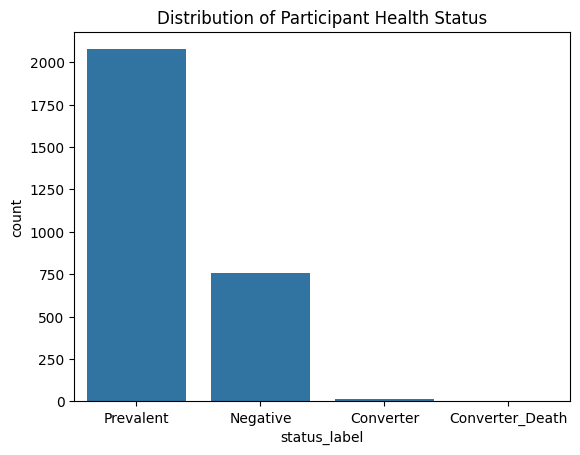

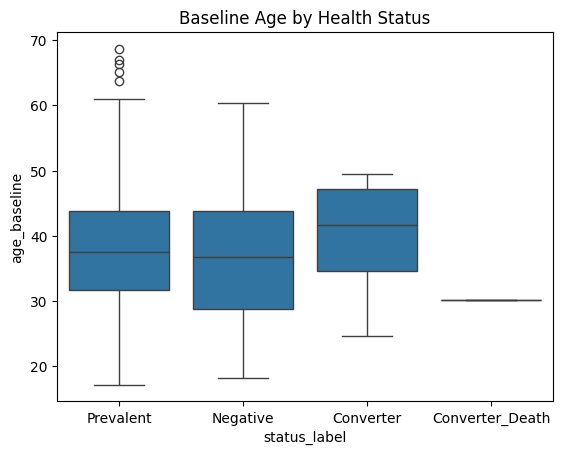

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=table1, x='status_label')
plt.title("Distribution of Participant Health Status")
plt.show()

sns.boxplot(data=table1, x='status_label', y='age_baseline')
plt.title("Baseline Age by Health Status")
plt.show()


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = table1[['bsvisit', 'age_baseline']].fillna(0)
y = table1['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         1.0       0.35      0.33      0.34       234
         2.0       0.75      0.76      0.75       616
         4.0       0.00      0.00      0.00         6

    accuracy                           0.64       856
   macro avg       0.36      0.36      0.36       856
weighted avg       0.63      0.64      0.63       856



In [36]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df_model = df.copy()

print("="*80)
print("STEP 1: EXPLORING MISSING VALUES")
print("="*80)

print("\n" + "-"*80)
print("UNDERSTANDING STATUS VALUES:")
print("-"*80)
status_map_explanation = {
    1: "Negative (HIV Negative)",
    2: "Prevalent (HIV Positive at baseline)",
    4: "Converter (Converted to HIV Positive during study)",
    5: "Converter_Death (Converted and died)"
}
for status_code, description in status_map_explanation.items():
    count = df_model[df_model['status'] == status_code].shape[0] if 'status' in df_model.columns else 0
    print(f"  Status {status_code}: {description:40s} (Count: {count:,})")

# Check missing values in key columns
key_columns = ['hemoglob', 'vload', 'CD4N', 'CD8N', 'CD4_8', 'ageatvis', 
               'status', 'race', 'genotype', 'nrti', 'nnrti', 'pi', 'anydrug']

print("\n" + "-"*80)
print("MISSING VALUES IN KEY COLUMNS:")
print("-"*80)
missing_summary = df_model[key_columns].isnull().sum()
missing_percent = (missing_summary / len(df_model)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

print(f"\n" + "-"*80)
print("DATASET SUMMARY:")
print("-"*80)
print(f"Total rows: {len(df_model):,}")
print(f"Rows with hemoglobin values: {df_model['hemoglob'].notna().sum():,}")
print(f"Rows missing hemoglobin: {df_model['hemoglob'].isna().sum():,}")

# Explain what the missing count means
print("\n" + "-"*80)
print("EXPLANATION:")
print("-"*80)
print("• 'Missing Count' = Number of rows where this variable has no value (NaN/null)")
print("• For 'status': 1 missing value means 1 row has no status recorded")
print("• Status values represent participant HIV status:")
print("  - Status 1 = Negative (HIV Negative)")
print("  - Status 2 = Prevalent (HIV Positive at baseline)")
print("  - Status 4 = Converter (Became HIV Positive during study)")
print("  - Status 5 = Converter_Death (Converted and died)")


STEP 1: EXPLORING MISSING VALUES

--------------------------------------------------------------------------------
UNDERSTANDING STATUS VALUES:
--------------------------------------------------------------------------------
  Status 1: Negative (HIV Negative)                  (Count: 12,492)
  Status 2: Prevalent (HIV Positive at baseline)     (Count: 33,011)
  Status 4: Converter (Converted to HIV Positive during study) (Count: 412)
  Status 5: Converter_Death (Converted and died)     (Count: 4)

--------------------------------------------------------------------------------
MISSING VALUES IN KEY COLUMNS:
--------------------------------------------------------------------------------
          Missing Count  Missing Percentage
hemoglob          31027           67.567509
genotype          26254           57.173345
anydrug           15243           33.194686
vload             13843           30.145906
nrti              12668           27.587108
nnrti             12668           27.58

In [37]:
#Working on predication model